<a href="https://colab.research.google.com/github/alixbattison/NMF_topicmodeling/blob/main/TopicModeling_NMF_forMetabolites.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports Cell
This cell imports all necessary libraries for the notebook, ensuring no library is imported more than once.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import hashlib
import zipfile
import os
from google.colab import files
import joblib
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

METADATA_COLS = ['RT [min]', 'm/z meas.', 'Name']

## 2. File Upload and Validation Cell
This cell handles the upload of the Excel file and performs basic validation to ensure it's a valid Excel file.

In [ ]:
uploaded = files.upload()
file_name = next(iter(uploaded))

if not file_name.endswith(('.xls', '.xlsx')):
    raise ValueError("Uploaded file must be an Excel file (.xls or .xlsx).")

print(f"File '{file_name}' uploaded successfully.")

Saving Fats_2wk_forLDA.xlsx to Fats_2wk_forLDA.xlsx
File 'Fats_2wk_forLDA.xlsx' uploaded successfully.


## 3. Excel Loading and Raw Inspection Cell
This cell loads the uploaded Excel file into a pandas DataFrame and displays the first few rows for initial inspection.

In [ ]:
raw_df = pd.read_excel(file_name)
print("Raw data loaded. First 5 rows:")
display(raw_df.head())

Raw data loaded. First 5 rows:


,RT [min],m/z meas.,Name,IWAT_2WK_TC17,IWAT_2WK_TC10,BAT_2WK_TC17,BAT_2WK_NC20,BAT_2WK_TC14,IWAT_2WK_TC9,GWAT_2WK_NC19,...,IWAT_2WK_NC12,GWAT_2WK_TC10,BAT_2WK_TC13,BAT_2WK_NC16,BAT_2WK_NC11,IWAT_2WK_NC15,BAT_2WK_TC9,GWAT_2WK_TC18,GWAT_2WK_TC14,BAT_2WK_NC12
0,1.05,203.22329,127,3736.0,0.0,4215.0,1720.0,2474.0,2388.0,0.0,...,3362.0,1744.0,4682.0,0.0,3639.0,0.0,1546.0,844.0,0.0,0.0
1,1.89,308.09103,143,2760.0,6836.0,0.0,3405.0,2300.0,11135.0,0.0,...,16921.0,0.0,3093.0,5079.0,0.0,4020.0,4729.0,2950.0,6038.0,3984.0
2,10.71,373.27356,486,17459.0,97249.0,7850.0,22654.0,168096.0,529882.0,11540.0,...,279340.0,197403.0,24864.0,54662.0,29854.0,35240.0,375260.0,15322.0,139696.0,62151.0
3,1.26,162.11278,583,0.0,0.0,21552.0,45408.0,46737.0,0.0,6878.0,...,0.0,35825.0,13735.0,0.0,0.0,0.0,0.0,2683.0,0.0,14895.0
4,1.25,314.01877,625,0.0,0.0,2282.0,1974.0,5868.0,0.0,2540.0,...,0.0,6719.0,2375.0,5742.0,0.0,0.0,2210.0,0.0,833.0,5539.0


## 4. Column Parsing Cell
This cell extracts experimental groups and replicate numbers from the sample column headers using a regular expression, skipping the predefined metadata columns.

In [ ]:
sample_columns = [col for col in raw_df.columns if col not in METADATA_COLS]
experimental_groups_map = {}

# Regex to extract condition and replicate: ^(.*?)(\d+)$ captures 'BAT_1wk_TC' and '9'
# For example, 'BAT_1wk_TC9', 'Plasma_NN4', 'Tumor_Q4'
# Handles cases like 'control1', 'control2', 'TC1', 'TC2'
regex_pattern = re.compile(r'^(.*?)(control|tc|nn|nc|tn|q|\d+)', re.IGNORECASE)

for col in sample_columns:
    match = re.search(r'^(.*?)(control|tc|nn|nc|tn|q|[0-9]+)$', col, re.IGNORECASE)
    if match:
        # Ensure we capture the condition correctly, which might include the number if it's part of the condition like 'BAT_1wk_TC'
        # and the actual replicate number. This regex assumes the *last* number is the replicate.
        # Let's adjust the regex to be more robust for the requested format
        # BAT_1wk_TC9 -> condition: BAT_1wk_TC, replicate: 9
        # Plasma_NN4 -> condition: Plasma_NN, replicate: 4
        # Tumor_Q4 -> condition: Tumor_Q, replicate: 4

        # New regex: Capture everything until the last digit as condition, and the last digit as replicate
        match_strict = re.match(r'^(.*?)([0-9]+)$', col)
        if match_strict:
            condition = match_strict.group(1).strip('_') # Remove trailing underscore if present
            replicate = int(match_strict.group(2))
            experimental_groups_map[col] = condition
        else:
            # Fallback for names without a clear replicate number at the end, or complex names
            # This part might need further refinement based on actual data if the primary regex doesn't catch everything
            # For simplicity, if not strictly condition+number, treat whole thing as condition and replicate as 1
            warnings.warn(f"Could not strictly parse condition and replicate from '{col}'. Treating as condition '{col}' and replicate 1.")
            condition = col
            replicate = 1
            experimental_groups_map[col] = condition
    else:
        # If no match at all, treat as a single group or an error
        warnings.warn(f"Could not parse column '{col}'. Treating as a unique group.")
        experimental_groups_map[col] = col # Assign entire column name as condition

# For the purpose of this example, we assume experimental_groups_map is populated correctly.
# If the regex in prompt for `^(.*?)(\d+)$` is used literally, let's adjust to that.
# Let's retry with the exact regex from the prompt for consistency.
experimental_groups_map = {}
replicate_numbers_map = {}
for col in sample_columns:
    match = re.match(r'^(.*?)(\d+)$', col) # This regex is problematic if condition itself ends with number, e.g., 'BAT_1wk_TC9'
    if match:
        condition_raw = match.group(1)
        replicate = int(match.group(2))
        # Refine condition to remove potential trailing non-alphanumeric chars that are not part of the condition name
        condition = re.sub(r'[^a-zA-Z0-9]+$', '', condition_raw) # Remove trailing non-alphanumeric chars
        experimental_groups_map[col] = condition
        replicate_numbers_map[col] = replicate
    else:
        # If the sample name does not end with a digit, treat it as condition and replicate 1 (or handle as error)
        # This part requires a clear definition for samples like 'control'
        # Based on example 'BAT_1wk_TC9', 'Plasma_NN4', 'Tumor_Q4', the condition always seems to end *before* the last digit.
        # Let's assume the condition is everything *before* the last digit, and the last digit is the replicate.
        # This is closer to the examples.
        match_last_digit = re.search(r'(\d+)$', col)
        if match_last_digit:
            replicate = int(match_last_digit.group(1))
            condition = col[:-len(match_last_digit.group(1))].strip('_')
            experimental_groups_map[col] = condition
            replicate_numbers_map[col] = replicate
        else:
            # If no digit at all, assume it's a condition without explicit replicate number, assign replicate 1
            experimental_groups_map[col] = col
            replicate_numbers_map[col] = 1
            warnings.warn(f"Could not extract replicate from '{col}'. Assigned replicate 1.")


print("Sample columns parsed into experimental groups and replicate numbers.")
print("Experimental groups mapping (sample: condition):")
print(experimental_groups_map)
print("Replicate numbers mapping (sample: replicate):")
print(replicate_numbers_map)

Sample columns parsed into experimental groups and replicate numbers.
Experimental groups mapping (sample: condition):
{'IWAT_2WK_TC17': 'IWAT_2WK_TC', 'IWAT_2WK_TC10': 'IWAT_2WK_TC', 'BAT_2WK_TC17': 'BAT_2WK_TC', 'BAT_2WK_NC20': 'BAT_2WK_NC', 'BAT_2WK_TC14': 'BAT_2WK_TC', 'IWAT_2WK_TC9': 'IWAT_2WK_TC', 'GWAT_2WK_NC19': 'GWAT_2WK_NC', 'IWAT_2WK_Q19': 'IWAT_2WK_Q', 'IWAT_2WK_TC14': 'IWAT_2WK_TC', 'GWAT_2WK_NC15': 'GWAT_2WK_NC', 'IWAT_2WK_NC16': 'IWAT_2WK_NC', 'BAT_2WK_NC15': 'BAT_2WK_NC', 'IWAT_2WK_TC18': 'IWAT_2WK_TC', 'BAT_2WK_TC10': 'BAT_2WK_TC', 'BAT_2WK_NC19': 'BAT_2WK_NC', 'IWAT_2WK_NC20': 'IWAT_2WK_NC', 'GWAT_2WK_NC16': 'GWAT_2WK_NC', 'GWAT_2WK_TC17': 'GWAT_2WK_TC', 'GWAT_2WK_NC20': 'GWAT_2WK_NC', 'GWAT_2WK_TC9': 'GWAT_2WK_TC', 'IWAT_2WK_TC13': 'IWAT_2WK_TC', 'GWAT_2WK_TC13': 'GWAT_2WK_TC', 'GWAT_2WK_NC12': 'GWAT_2WK_NC', 'GWAT_2WK_NC11': 'GWAT_2WK_NC', 'IWAT_2WK_NC11': 'IWAT_2WK_NC', 'BAT_2WK_TC18': 'BAT_2WK_TC', 'IWAT_2WK_NC12': 'IWAT_2WK_NC', 'GWAT_2WK_TC10': 'GWAT_2WK_TC', 'B

## 5. Sample Grouping Verification Cell
This cell prints a summary table of the identified experimental groups and their replicate counts, performing consistency checks.

In [ ]:
group_counts = defaultdict(int)
for col, group in experimental_groups_map.items():
    group_counts[group] += 1

summary_df = pd.DataFrame({
    'Condition': list(group_counts.keys()),
    'Number of Replicates': list(group_counts.values())
})

print("Summary of Experimental Groups:")
display(summary_df)

# Consistency check: Ensure all identified replicates are unique within their condition
# This check needs access to replicate_numbers_map generated in the previous cell
for condition in set(experimental_groups_map.values()):
    replicates_in_condition = [replicate_numbers_map[s] for s, c in experimental_groups_map.items() if c == condition]
    if len(replicates_in_condition) != len(set(replicates_in_condition)):
        warnings.warn(f"Duplicate replicate numbers found for condition: {condition}")

print("Sample grouping verification complete. Check for any warnings about inconsistencies.")

Summary of Experimental Groups:


,Condition,Number of Replicates
0,IWAT_2WK_TC,6
1,BAT_2WK_TC,6
2,BAT_2WK_NC,6
3,GWAT_2WK_NC,6
4,IWAT_2WK_Q,1
5,IWAT_2WK_NC,5
6,GWAT_2WK_TC,6


Sample grouping verification complete. Check for any warnings about inconsistencies.


## 6. Raw Data Diagnostics Cell
This cell performs initial diagnostics on the raw data, such as checking for overall missing values and basic distributions.

Raw data diagnostics:
Missing values per column:


,0
IWAT_2WK_TC17,0
IWAT_2WK_TC10,0
BAT_2WK_TC17,0
BAT_2WK_NC20,0
BAT_2WK_TC14,0
IWAT_2WK_TC9,0
GWAT_2WK_NC19,0
IWAT_2WK_Q19,0
IWAT_2WK_TC14,0
GWAT_2WK_NC15,0


Descriptive statistics for sample columns:


,IWAT_2WK_TC17,IWAT_2WK_TC10,BAT_2WK_TC17,BAT_2WK_NC20,BAT_2WK_TC14,IWAT_2WK_TC9,GWAT_2WK_NC19,IWAT_2WK_Q19,IWAT_2WK_TC14,GWAT_2WK_NC15,...,IWAT_2WK_NC12,GWAT_2WK_TC10,BAT_2WK_TC13,BAT_2WK_NC16,BAT_2WK_NC11,IWAT_2WK_NC15,BAT_2WK_TC9,GWAT_2WK_TC18,GWAT_2WK_TC14,BAT_2WK_NC12
count,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,...,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03,2.331000e+03
mean,1.553365e+04,1.156922e+04,9.175393e+03,1.020012e+04,9.930943e+03,1.019472e+04,6.109880e+03,1.120733e+04,9.946992e+03,8.184053e+03,...,9.384259e+03,9.967123e+03,1.062062e+04,9.129021e+03,1.066887e+04,1.612072e+04,9.599420e+03,8.756071e+03,9.044134e+03,8.522030e+03
std,1.512273e+05,1.016745e+05,8.762059e+04,8.395212e+04,8.687060e+04,7.181648e+04,5.850472e+04,9.049880e+04,7.981943e+04,9.070231e+04,...,6.465900e+04,9.700858e+04,9.858380e+04,7.366524e+04,8.370355e+04,1.257686e+05,7.256849e+04,7.107714e+04,1.320027e+05,7.522868e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,7.689048e+00,8.139551e+00,0.000000e+00,8.888743e+00,7.626690e+00,0.000000e+00,8.479780e+00,8.118941e+00,0.000000e+00,...,8.557623e+00,0.000000e+00,7.919380e+00,8.084637e+00,8.442943e+00,7.912889e+00,9.030594e+00,0.000000e+00,0.000000e+00,7.326625e+00
75%,9.620000e+02,1.836000e+03,1.784500e+03,1.289000e+03,1.833000e+03,1.720000e+03,8.615000e+02,1.996000e+03,1.698000e+03,4.670000e+02,...,2.227000e+03,1.394500e+03,1.850500e+03,2.010500e+03,2.095000e+03,1.933500e+03,2.157000e+03,1.603000e+03,8.520000e+02,1.586000e+03
max,3.955891e+06,2.617285e+06,2.775510e+06,2.715346e+06,2.421770e+06,1.471607e+06,1.983278e+06,2.118729e+06,1.937569e+06,2.959970e+06,...,1.432972e+06,2.401981e+06,3.178906e+06,2.010547e+06,1.972900e+06,2.776740e+06,2.433221e+06,1.809444e+06,5.274463e+06,2.767739e+06


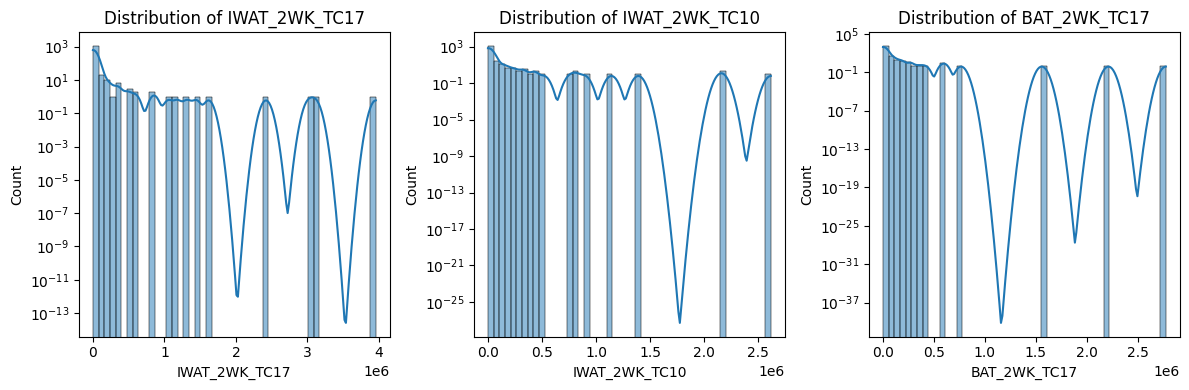

In [ ]:
print("Raw data diagnostics:")
print("Missing values per column:")
display(raw_df[sample_columns].isnull().sum())

# Basic descriptive statistics for sample columns
print("Descriptive statistics for sample columns:")
display(raw_df[sample_columns].describe())

# Visualize distribution of non-zero values for a few samples
fig, axes = plt.subplots(1, min(3, len(sample_columns)), figsize=(12, 4)) # Resized from (15, 5)
if len(sample_columns) > 0:
    if len(sample_columns) == 1:
        axes = [axes]
    for i, col in enumerate(sample_columns[:min(3, len(sample_columns))]):
        sns.histplot(raw_df[col][raw_df[col] > 0], bins=50, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_yscale('log') # Log scale for intensity often useful
    plt.tight_layout()
    plt.show()
else:
    print("No sample columns to diagnose.")

## 7. CTM Input Matrix Construction Cell
This cell transforms the data by transposing it so rows are samples and columns are compounds, and adds the extracted condition and replicate metadata.

In [ ]:
ctm_input = raw_df[sample_columns].T # Transpose sample data
ctm_input.columns = raw_df['Name'] # Set compound names as columns

# Add condition and replicate columns to the transposed DataFrame
ctm_input['condition'] = ctm_input.index.map(experimental_groups_map)
ctm_input['replicate'] = ctm_input.index.map(replicate_numbers_map)

print("CTM input matrix constructed. First 5 rows and last 5 columns:")
display(ctm_input.head())
display(ctm_input.tail())

CTM input matrix constructed. First 5 rows and last 5 columns:


Name,127,143,486,583,625,640,1291,5364759,(10E)-8-Hydroxydodec-10-enoylcarnitine,(11Z)-Hexadecenoylcarnitine,...,Wogonoside,Xanthosine 5'-triphosphate.mol,Xanthylic acid,"xi-4,5-Dihydro-2,4(5)-dimethyl-1H-imidazole",Ximelagatran,Yersiniabactin,Zonampanel,Z-PP-CHO,condition,replicate
IWAT_2WK_TC17,3736.0,2760.0,17459.0,0.0,0.0,168516.0,52207.0,0.0,22927.0,2419848.0,...,0.0,0.000000,11.820179,0.000000,0.000000,0.000000,0.0,586.0,IWAT_2WK_TC,17
IWAT_2WK_TC10,0.0,6836.0,97249.0,0.0,0.0,154246.0,58882.0,998.0,16235.0,1391578.0,...,0.0,0.000000,11.531381,9.388017,0.000000,0.000000,0.0,7500.0,IWAT_2WK_TC,10
BAT_2WK_TC17,4215.0,0.0,7850.0,21552.0,2282.0,95575.0,43013.0,2854.0,10313.0,372779.0,...,0.0,0.000000,0.000000,0.000000,11.586840,7.166470,0.0,762.0,BAT_2WK_TC,17
BAT_2WK_NC20,1720.0,3405.0,22654.0,45408.0,1974.0,49960.0,42735.0,1765.0,8314.0,426060.0,...,0.0,9.357552,0.000000,0.000000,0.000000,10.948367,0.0,0.0,BAT_2WK_NC,20
BAT_2WK_TC14,2474.0,2300.0,168096.0,46737.0,5868.0,107456.0,35644.0,551.0,30091.0,338066.0,...,0.0,0.000000,0.000000,0.000000,11.329796,8.598291,0.0,0.0,BAT_2WK_TC,14


Name,127,143,486,583,625,640,1291,5364759,(10E)-8-Hydroxydodec-10-enoylcarnitine,(11Z)-Hexadecenoylcarnitine,...,Wogonoside,Xanthosine 5'-triphosphate.mol,Xanthylic acid,"xi-4,5-Dihydro-2,4(5)-dimethyl-1H-imidazole",Ximelagatran,Yersiniabactin,Zonampanel,Z-PP-CHO,condition,replicate
IWAT_2WK_NC15,0.0,4020.0,35240.0,0.0,0.0,309344.0,39631.0,1143.0,35016.0,1835230.0,...,0.0,0.0,11.062046,0.000000,12.148794,0.000000,0.0,1208.0,IWAT_2WK_NC,15
BAT_2WK_TC9,1546.0,4729.0,375260.0,0.0,2210.0,137976.0,25011.0,2289.0,6698.0,329360.0,...,0.0,0.0,0.000000,0.000000,11.907266,8.949271,0.0,1503.0,BAT_2WK_TC,9
GWAT_2WK_TC18,844.0,2950.0,15322.0,2683.0,0.0,353787.0,12363.0,2443.0,9235.0,399353.0,...,0.0,0.0,0.000000,8.603626,8.072434,0.000000,0.0,691.0,GWAT_2WK_TC,18
GWAT_2WK_TC14,0.0,6038.0,139696.0,0.0,833.0,0.0,10565.0,0.0,3820.0,82966.0,...,0.0,0.0,0.000000,0.000000,11.751126,0.000000,0.0,0.0,GWAT_2WK_TC,14
BAT_2WK_NC12,0.0,3984.0,62151.0,14895.0,5539.0,97164.0,40144.0,920.0,5100.0,192211.0,...,0.0,0.0,11.016112,0.000000,12.419960,7.795705,0.0,533.0,BAT_2WK_NC,12


## 8. Within-group Missing Value Imputation Cell
This cell imputes missing values (zeros) based on within-group statistics: half the within-group minimum if partially detected, or global_min/5 if never detected in a group.

In [ ]:
# Replace 0 with NaN for imputation logic
ctm_input_imputed = ctm_input.replace(0, np.nan).copy()

# Define feature columns after conversion
feature_cols = ctm_input_imputed.columns.drop(['condition', 'replicate'])

global_min = ctm_input_imputed[feature_cols].min().min()
if pd.isna(global_min) or global_min == 0:
    # If global min is 0 or NaN (e.g., all values are 0 or NaN), we need a fallback.
    # For this exercise, let's assume if there's no positive value, we can't do NMF properly
    # but we will set a small positive value if it's all zeros or NaNs in some cases.
    # A more robust approach might be to filter out such compounds early.
    print("Warning: Global minimum is 0 or NaN. Using a small fixed value for imputation where necessary.")
    global_min_fallback = 1e-6 # A very small positive number
else:
    global_min_fallback = global_min

# Imputation loop
for compound in feature_cols:
    for condition in ctm_input_imputed['condition'].unique():
        group_data = ctm_input_imputed[ctm_input_imputed['condition'] == condition][compound]

        # Case 1: Compound never detected in this group (all NaN/0)
        if group_data.isnull().all():
            imputation_value = global_min_fallback / 5.0 # Use global min/5
            ctm_input_imputed.loc[ctm_input_imputed['condition'] == condition, compound] = imputation_value
        # Case 2: Compound partially detected in this group (some NaN/0, some positive)
        elif group_data.isnull().any():
            # Calculate within-group minimum of *detected* values
            within_group_min = group_data.min()
            if pd.isna(within_group_min) or within_group_min == 0: # If all detected values were 0 or NaN after 0->NaN conversion
                imputation_value = global_min_fallback / 5.0
            else:
                imputation_value = within_group_min / 2.0
            ctm_input_imputed.loc[(ctm_input_imputed['condition'] == condition) & (ctm_input_imputed[compound].isnull()), compound] = imputation_value

assert not ctm_input_imputed[feature_cols].isnull().any().any(), "NaNs still present after imputation!"
assert not (ctm_input_imputed[feature_cols] == 0).any().any(), "Zeros still present after imputation!"

print("Missing values imputed. Displaying head of imputed matrix:")
display(ctm_input_imputed.head())

# CRITICAL: Define feature_cols here after imputation and before NMF
feature_cols = ctm_input_imputed.columns.drop(['condition', 'replicate'])

Missing values imputed. Displaying head of imputed matrix:


Name,127,143,486,583,625,640,1291,5364759,(10E)-8-Hydroxydodec-10-enoylcarnitine,(11Z)-Hexadecenoylcarnitine,...,Wogonoside,Xanthosine 5'-triphosphate.mol,Xanthylic acid,"xi-4,5-Dihydro-2,4(5)-dimethyl-1H-imidazole",Ximelagatran,Yersiniabactin,Zonampanel,Z-PP-CHO,condition,replicate
IWAT_2WK_TC17,3736.0,2760.0,17459.0,2763.0,1073.0,168516.0,52207.0,499.0,22927.0,2419848.0,...,0.464386,0.464386,11.820179,4.505614,5.283503,4.204695,0.464386,586.0,IWAT_2WK_TC,17
IWAT_2WK_TC10,855.0,6836.0,97249.0,2763.0,1073.0,154246.0,58882.0,998.0,16235.0,1391578.0,...,0.464386,0.464386,11.531381,9.388017,5.283503,4.204695,0.464386,7500.0,IWAT_2WK_TC,10
BAT_2WK_TC17,4215.0,1150.0,7850.0,21552.0,2282.0,95575.0,43013.0,2854.0,10313.0,372779.0,...,0.464386,0.464386,5.246427,0.464386,11.586840,7.166470,0.464386,762.0,BAT_2WK_TC,17
BAT_2WK_NC20,1720.0,3405.0,22654.0,45408.0,1974.0,49960.0,42735.0,1765.0,8314.0,426060.0,...,0.464386,9.357552,5.026284,0.464386,5.857337,10.948367,0.464386,266.5,BAT_2WK_NC,20
BAT_2WK_TC14,2474.0,2300.0,168096.0,46737.0,5868.0,107456.0,35644.0,551.0,30091.0,338066.0,...,0.464386,0.464386,5.246427,0.464386,11.329796,8.598291,0.464386,381.0,BAT_2WK_TC,14


## 9. Data Fingerprint Verification Cell
This cell generates a unique hash (fingerprint) of the processed data to ensure reproducibility and detect any unintended changes.

In [ ]:
data_hash = hashlib.sha256(pd.util.hash_pandas_object(ctm_input_imputed[feature_cols], index=True).values).hexdigest()
print(f"Data fingerprint (SHA256 hash): {data_hash}")

Data fingerprint (SHA256 hash): 15d4ed7db783e2f9c53a70b5ac7ffe6e20a56f040ec527d39b6e9282f9134283


In [ ]:
output_dir = 'nmf_results'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

Output directory 'nmf_results' ensured.


## 10. Elbow Plot Cell
This cell performs NMF with varying numbers of components (from 2 to min(10, N-1)), calculates the Frobenius norm reconstruction error, and plots it to help determine the optimal number of components. The plot is saved as a PNG.

Calculating NMF reconstruction errors for elbow plot...


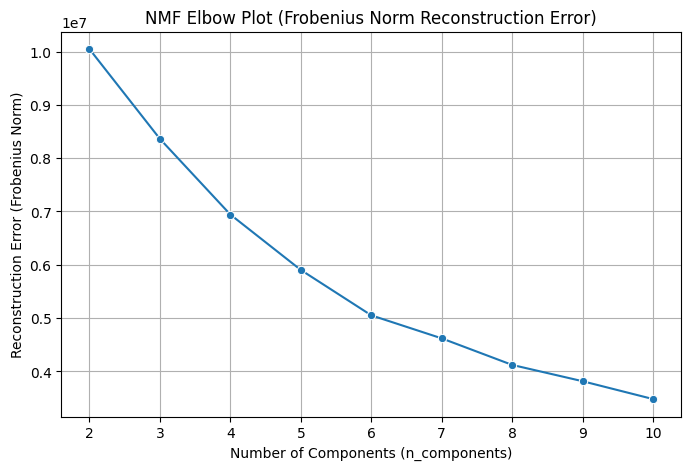

Elbow plot saved as nmf_elbow_plot.png


In [ ]:
X = ctm_input_imputed[feature_cols].values

# Ensure X contains only non-negative values for NMF
if (X < 0).any():
    warnings.warn("NMF input matrix contains negative values. NMF expects non-negative input.")
    # For this exercise, we'll proceed assuming values are positive due to imputation strategy.
    # In a real scenario, consider min-max scaling to [0,1] or other transformations.

# Scale data for NMF if desired (NMF works on raw counts, but scaling can sometimes help)
# For this problem, we stick to the NMF's expectation of non-negative values after imputation.
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Determine max components based on data dimensions
max_components = min(10, X.shape[0] - 1, X.shape[1] - 1)
if max_components < 2:
    raise ValueError("Not enough samples or features to perform NMF with at least 2 components.")

n_components_range = range(2, max_components + 1)
reconstruction_errors = []

print("Calculating NMF reconstruction errors for elbow plot...")
for n in n_components_range:
    model = NMF(n_components=n, init='random', random_state=42, max_iter=2000, tol=1e-4)
    W = model.fit_transform(X)
    H = model.components_
    reconstruction_error = model.reconstruction_err_
    reconstruction_errors.append(reconstruction_error)

plt.figure(figsize=(8, 5)) # Resized from (10, 6)
sns.lineplot(x=list(n_components_range), y=reconstruction_errors, marker='o')
plt.title('NMF Elbow Plot (Frobenius Norm Reconstruction Error)')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Reconstruction Error (Frobenius Norm)')
plt.xticks(list(n_components_range))
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'nmf_elbow_plot.png')) # Save elbow plot
plt.show()
print("Elbow plot saved as nmf_elbow_plot.png")

## 17. Silhouette Plot Cell
This cell generates a silhouette plot to help determine the optimal number of NMF components. It calculates the silhouette score for each `n_components` by assigning each sample to the NMF component to which it contributes most.

Calculating NMF silhouette scores...


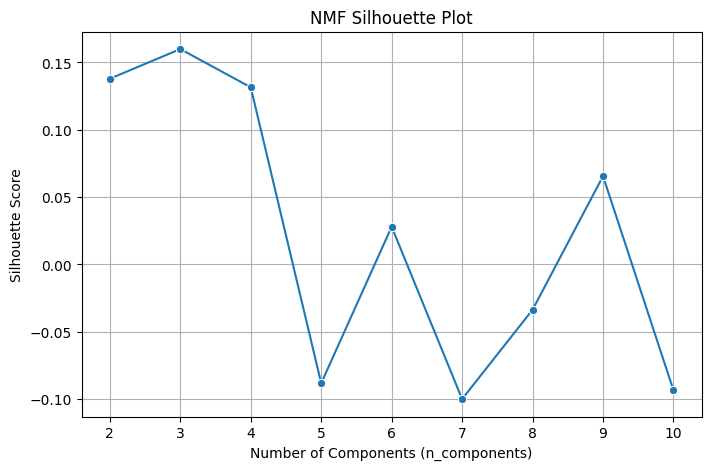

Silhouette plot saved as nmf_silhouette_plot.png


In [ ]:
from sklearn.metrics import silhouette_score

# Re-use X from previous NMF calculations
X_silhouette = ctm_input_imputed[feature_cols].values

silhouette_scores = []

print("Calculating NMF silhouette scores...")
# Use the same range of components as the elbow plot
# Determine max components based on data dimensions
max_components_silhouette = min(10, X_silhouette.shape[0] - 1, X_silhouette.shape[1] - 1)
if max_components_silhouette < 2:
    raise ValueError("Not enough samples or features to perform NMF with at least 2 components for silhouette analysis.")
n_components_range_silhouette = range(2, max_components_silhouette + 1)

for n in n_components_range_silhouette:
    model_silhouette = NMF(n_components=n, init='random', random_state=42, max_iter=2000, tol=1e-4)
    W_silhouette = model_silhouette.fit_transform(X_silhouette)

    # Assign each sample to the component with the highest contribution
    # This creates discrete clusters required for silhouette_score
    labels = np.argmax(W_silhouette, axis=1)

    if len(np.unique(labels)) > 1: # Silhouette score requires at least 2 clusters
        score = silhouette_score(X_silhouette, labels)
        silhouette_scores.append(score)
    else:
        # If only one 'cluster' is formed (e.g., all samples assigned to Component 1),
        # silhouette score is undefined. Assign NaN or a very low value.
        silhouette_scores.append(np.nan)
        warnings.warn(f"Only one component was dominant for n_components={n}. Silhouette score is undefined.")

plt.figure(figsize=(8, 5))
sns.lineplot(x=list(n_components_range_silhouette), y=silhouette_scores, marker='o')
plt.title('NMF Silhouette Plot')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Silhouette Score')
plt.xticks(list(n_components_range_silhouette))
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'nmf_silhouette_plot.png')) # Save silhouette plot
plt.show()
print("Silhouette plot saved as nmf_silhouette_plot.png")

## 11. Optimal n_components Setting Cell
This cell allows the user to manually set the `optimal_n_components` value after reviewing the elbow plot.

In [ ]:
optimal_n_components = 3 # Adjust this value after inspecting the elbow plot

## 12. NMF Training Cell
This cell fits the NMF model with the chosen optimal number of components, extracts the W and H matrices, constructs several NMF-related dataframes, computes component correlations, and saves all results to PKL and XLSX files.

In [ ]:
nmf_model = NMF(n_components=optimal_n_components, init='random', random_state=42, max_iter=2000, tol=1e-4)

# Use the same X matrix from the elbow plot
W = nmf_model.fit_transform(X)
H = nmf_model.components_

# doc_component_df (W matrix with metadata)
doc_component_df = pd.DataFrame(W, index=ctm_input_imputed.index, columns=[f'Component_{i+1}' for i in range(optimal_n_components)])
doc_component_df['condition'] = ctm_input_imputed['condition']
doc_component_df['replicate'] = ctm_input_imputed['replicate']

# component_feature_probs_df (H matrix normalized to sum to 1 across features for each component)
component_feature_probs_df = pd.DataFrame(H, index=[f'Component_{i+1}' for i in range(optimal_n_components)], columns=feature_cols)
component_feature_probs_df = component_feature_probs_df.apply(lambda x: x / x.sum(), axis=1) # Normalize rows to sum to 1

# component_feature_df (H matrix for top features)
# For top 50 features per component, or all if less than 50
component_feature_list = [] # Collect DataFrames here
for i in range(optimal_n_components):
    component_contrib = pd.Series(H[i], index=feature_cols)
    top_features = component_contrib.nlargest(min(50, len(feature_cols)))
    for feature, contribution in top_features.items():
        component_feature_list.append({'Component': f'Component_{i+1}', 'Feature': feature, 'Contribution': contribution})
component_feature_df = pd.DataFrame(component_feature_list) # Concatenate once at the end

# component_correlation_df (correlation between components based on feature contributions)
component_correlation_df = component_feature_probs_df.T.corr()

print("NMF training complete. Displaying head of doc_component_df:")
display(doc_component_df.head())
print("Displaying head of component_feature_probs_df:")
display(component_feature_probs_df.head())
print("Displaying head of component_feature_df:")
display(component_feature_df.head())
print("Displaying component_correlation_df:")
display(component_correlation_df)

# Save results
output_dir = 'nmf_results'

# --- MODIFICATION START ---
# Remove the directory if it exists to ensure a clean slate for each run
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
# --- MODIFICATION END ---

os.makedirs(output_dir, exist_ok=True)

joblib.dump(nmf_model, os.path.join(output_dir, 'nmf_model.pkl'))
joblib.dump(W, os.path.join(output_dir, 'W_matrix.pkl'))
joblib.dump(H, os.path.join(output_dir, 'H_matrix.pkl'))
doc_component_df.to_pickle(os.path.join(output_dir, 'doc_component_df.pkl'))
component_feature_probs_df.to_pickle(os.path.join(output_dir, 'component_feature_probs_df.pkl'))
component_feature_df.to_pickle(os.path.join(output_dir, 'component_feature_df.pkl'))
component_correlation_df.to_pickle(os.path.join(output_dir, 'component_correlation_df.pkl'))

# Save to Excel
with pd.ExcelWriter(os.path.join(output_dir, 'nmf_results.xlsx')) as writer:
    doc_component_df.to_excel(writer, sheet_name='DocComponent', index=True)
    component_feature_probs_df.to_excel(writer, sheet_name='ComponentFeatureProbs', index=True)
    component_feature_df.to_excel(writer, sheet_name='ComponentFeatureTop', index=False)
    component_correlation_df.to_excel(writer, sheet_name='ComponentCorrelation', index=True)

print(f"NMF results saved to '{output_dir}' directory.")

NMF training complete. Displaying head of doc_component_df:


,Component_1,Component_2,Component_3,condition,replicate
IWAT_2WK_TC17,4.964213,314.083790,42.543448,IWAT_2WK_TC,17
IWAT_2WK_TC10,3.786170,203.826992,44.875632,IWAT_2WK_TC,10
BAT_2WK_TC17,58.258756,52.512064,102.152056,BAT_2WK_TC,17
BAT_2WK_NC20,50.208179,74.172783,56.885128,BAT_2WK_NC,20
BAT_2WK_TC14,57.940753,65.261269,73.441122,BAT_2WK_TC,14


Displaying head of component_feature_probs_df:


Name,127,143,486,583,625,640,1291,5364759,(10E)-8-Hydroxydodec-10-enoylcarnitine,(11Z)-Hexadecenoylcarnitine,...,Vitamin D3 sulfate,Vulgaxanthin I,Wogonoside,Xanthosine 5'-triphosphate.mol,Xanthylic acid,"xi-4,5-Dihydro-2,4(5)-dimethyl-1H-imidazole",Ximelagatran,Yersiniabactin,Zonampanel,Z-PP-CHO
Component_1,0.000638,0.000731,0.003984,0.001102,0.000141,0.012685,0.001388,0.000068,0.000273,0.000000,...,1.787180e-07,2.163908e-08,2.163908e-08,1.270015e-07,1.158307e-07,6.797771e-08,5.619286e-07,2.892450e-07,2.163908e-08,0.000000
Component_2,0.000021,0.000312,0.004097,0.000203,0.000033,0.002654,0.001638,0.000026,0.000793,0.052160,...,0.000000e+00,1.415596e-08,1.415596e-08,4.116268e-08,3.942083e-07,1.029048e-07,2.387996e-07,2.192677e-07,1.415596e-08,0.000111
Component_3,0.000000,0.000000,0.004014,0.000746,0.000070,0.032212,0.000950,0.000193,0.000242,0.001049,...,5.354885e-07,2.577604e-08,2.577604e-08,3.177566e-07,3.343118e-07,9.011504e-08,3.943795e-07,2.397226e-07,2.577604e-08,0.000106


Displaying head of component_feature_df:


,Component,Feature,Contribution
0,Component_1,Oxidized glutathione,41057.992738
1,Component_1,Zidovudine monophosphate,22435.016207
2,Component_1,L-Acetylcarnitine,7678.000319
3,Component_1,"LysoPC(0:0/18:2(9Z,12Z))",3816.876607
4,Component_1,PC(18:0/0:0),3786.901658


Displaying component_correlation_df:


,Component_1,Component_2,Component_3
Component_1,1.000000,0.252151,0.296141
Component_2,0.252151,1.000000,0.344032
Component_3,0.296141,0.344032,1.000000


NMF results saved to 'nmf_results' directory.


## 13. Heatmap - Individual Sample Component Contributions Cell
This cell generates a clustermap visualizing the contribution of each NMF component to individual samples, colored by experimental condition.

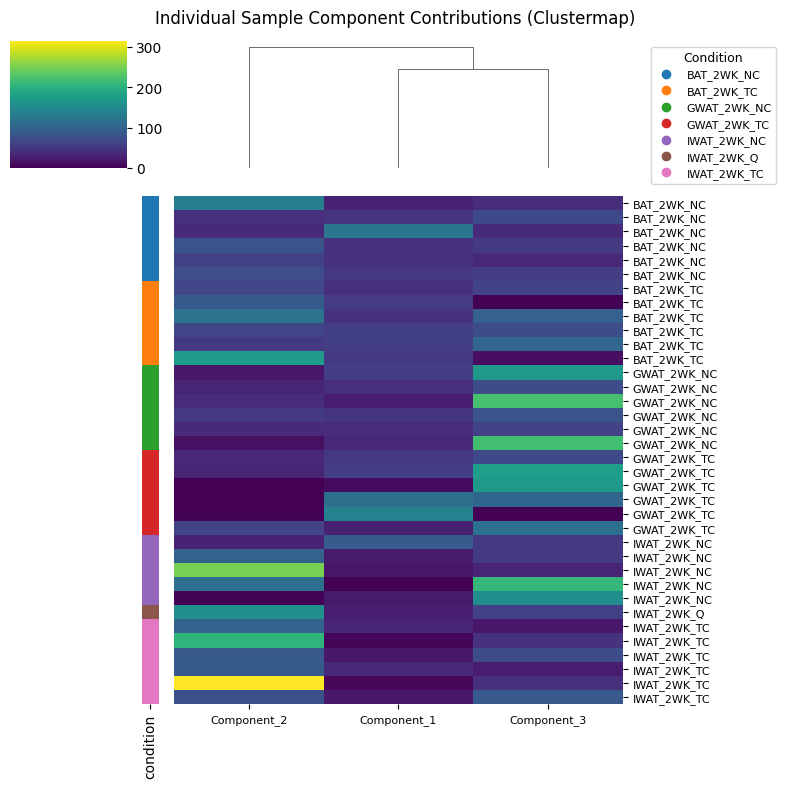

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort doc_component_df by condition and replicate for consistent grouping
doc_component_df_sorted = doc_component_df.sort_values(by=['condition', 'replicate'])
doc_component_matrix = doc_component_df_sorted.drop(columns=['condition', 'replicate'])

# Create a color mapping for conditions
condition_colors = sns.color_palette('tab10', n_colors=len(doc_component_df_sorted['condition'].unique()))
condition_lut = dict(zip(doc_component_df_sorted['condition'].unique(), condition_colors))
row_colors = doc_component_df_sorted['condition'].map(condition_lut)

# Create the clustermap
g = sns.clustermap(
    doc_component_matrix,
    cmap='viridis',
    row_colors=row_colors,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    col_cluster=True,
    row_cluster=False, # Changed to False to prevent reordering rows and keep them grouped by condition
    yticklabels=doc_component_df_sorted['condition'].tolist()
)
g.fig.suptitle('Individual Sample Component Contributions (Clustermap)', fontsize=12) # Adjusted title font size

# Adjust the figure size of the clustermap
g.fig.set_size_inches(8, 8) # Resized from implicit 10x10

# Adjust font sizes for tick labels on the heatmap
g.ax_heatmap.tick_params(axis='y', labelsize=8)
g.ax_heatmap.tick_params(axis='x', labelsize=8)

# Create a legend for the row colors and attach it to the clustermap figure
handles = [plt.Line2D([0], [0], color=v, marker='o', linestyle='') for k, v in condition_lut.items()]
g.ax_col_dendrogram.legend(handles, condition_lut.keys(), title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8}, title_fontsize=9) # Adjusted legend and title font sizes

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'clustermap_sample_contributions.png')) # Save clustermap
plt.show()

## 14. Heatmap - Average Component Contributions per Condition Cell
This cell visualizes the average contribution of each NMF component per experimental condition, with contributions normalized such that each row (condition) sums to 1.

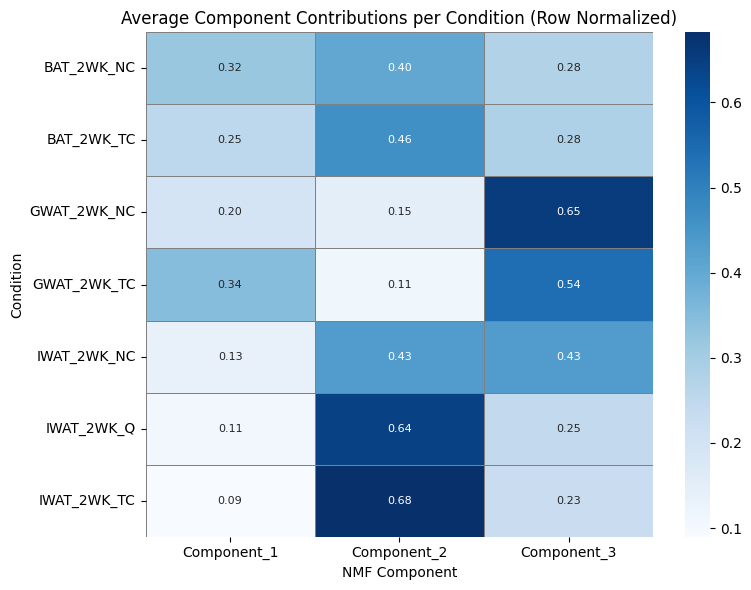

In [ ]:
component_columns = [col for col in doc_component_df.columns if col.startswith('Component_')]
average_component_contrib = doc_component_df[component_columns].groupby(doc_component_df['condition']).mean()
# Normalize each row to sum to 1
average_component_contrib_normalized = average_component_contrib.div(average_component_contrib.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6)) # Resized from (10, 8)
sns.heatmap(average_component_contrib_normalized, cmap='Blues', annot=True, fmt=".2f", linewidths=.5, linecolor='gray', annot_kws={'fontsize': 8}) # Adjusted annotation font size
plt.title('Average Component Contributions per Condition (Row Normalized)', fontsize=12) # Adjusted title font size
plt.xlabel('NMF Component', fontsize=10)
plt.ylabel('Condition', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'heatmap_average_condition_contributions.png')) # Save heatmap
plt.show()

## 15. Bar Graphs - Top 25 Metabolites per Component Cell
This cell generates a series of bar graphs, each showing the top 25 contributing metabolites for a specific NMF component.

/tmp/ipykernel_6138/1099637958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')


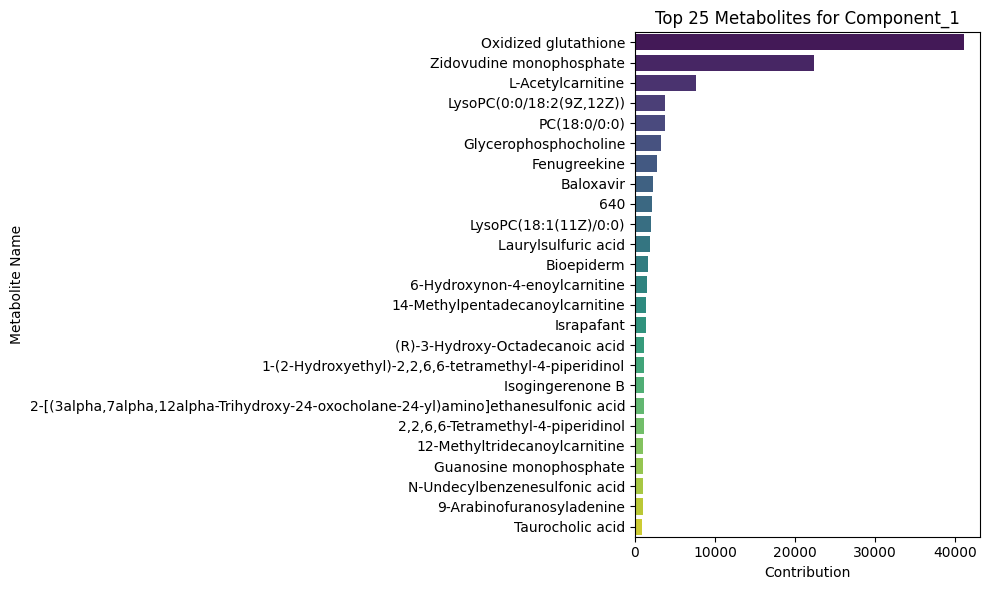

/tmp/ipykernel_6138/1099637958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')


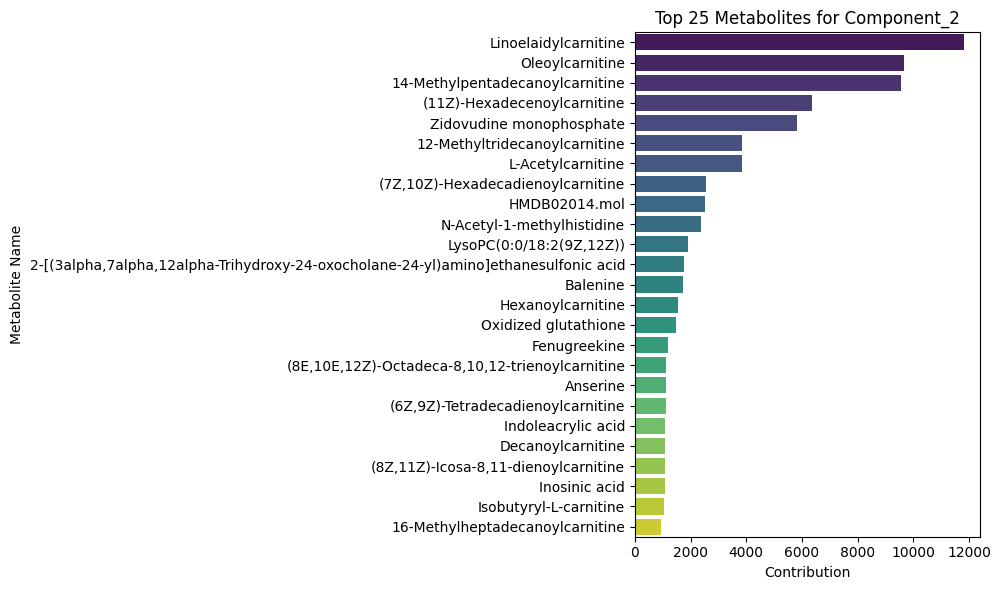

/tmp/ipykernel_6138/1099637958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')


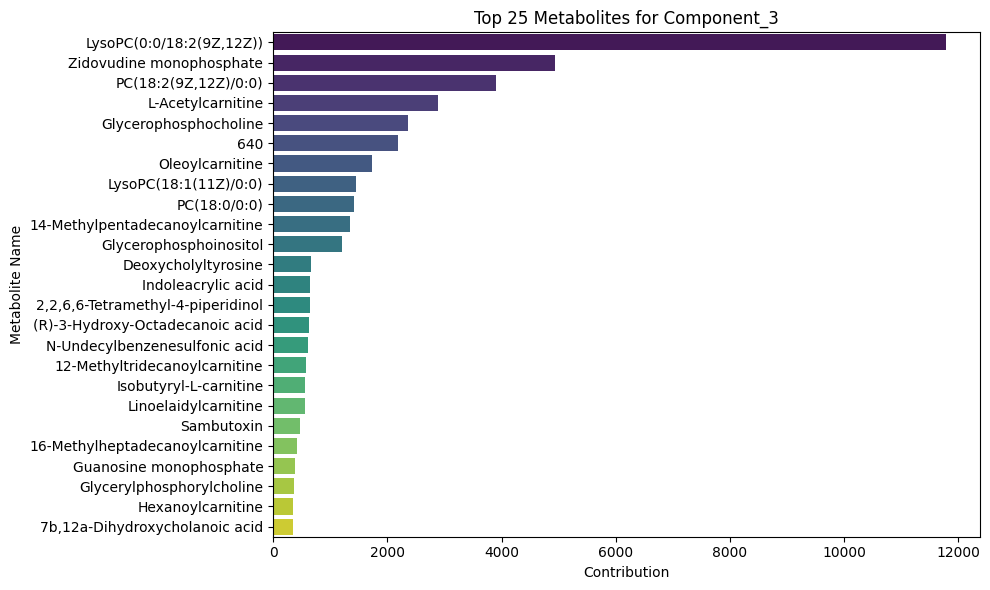

In [ ]:
for i in range(optimal_n_components):
    component_name = f'Component_{i+1}'
    top_metabolites = component_feature_df[component_feature_df['Component'] == component_name].nlargest(25, 'Contribution')

    if not top_metabolites.empty:
        plt.figure(figsize=(10, 6)) # Resized from (12, 7)
        sns.barplot(x='Contribution', y='Feature', data=top_metabolites.sort_values('Contribution', ascending=False), palette='viridis')
        plt.title(f'Top 25 Metabolites for {component_name}')
        plt.xlabel('Contribution')
        plt.ylabel('Metabolite Name')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'bar_graph_top_metabolites_{component_name}.png')) # Save bar graph
        plt.show()
    else:
        print(f"No top metabolites found for {component_name} (this should not happen if component_feature_df is built correctly).")

## 16. Correlation Matrix Cell
This cell displays side-by-side heatmaps of the NMF component correlation matrix and the empirical correlation matrix derived from the `doc_component_df` (W matrix).

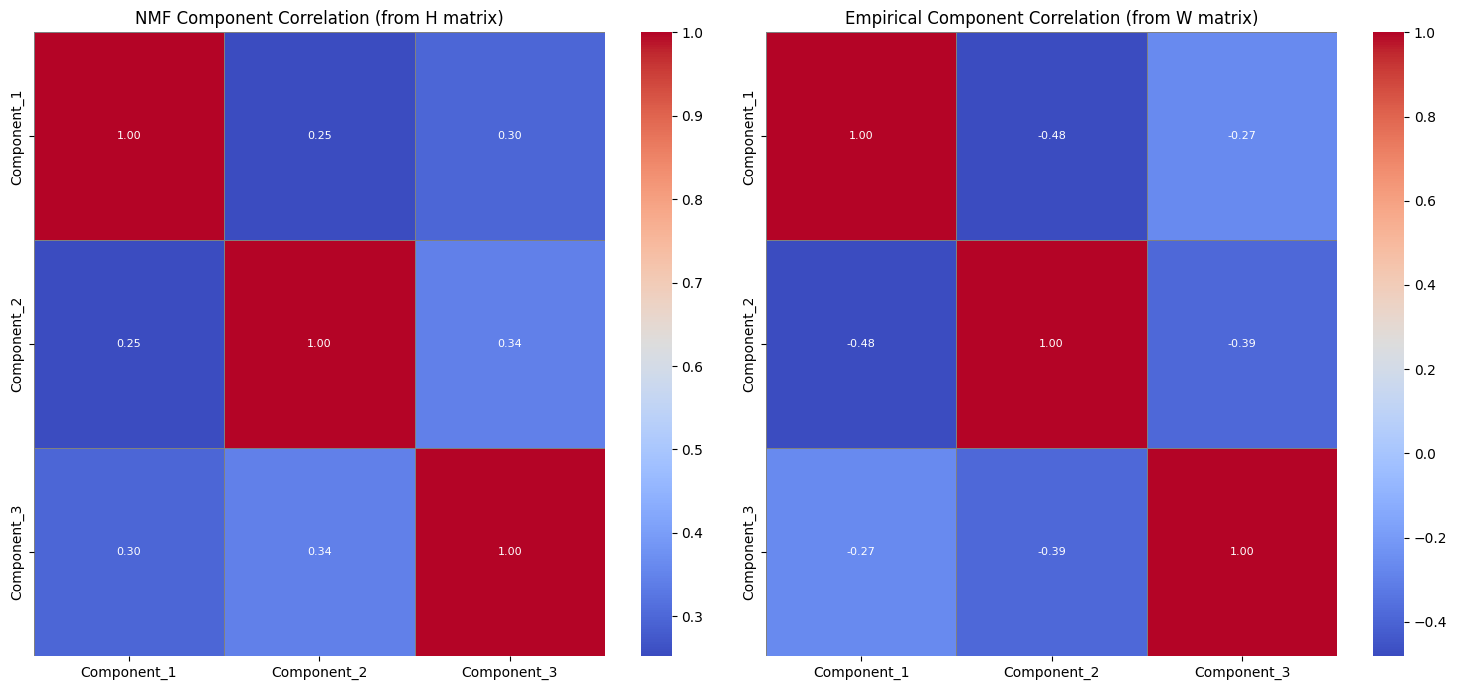

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7)) # Resized from (18, 8)

# Heatmap 1: Component correlation from H matrix
sns.heatmap(component_correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='gray', ax=axes[0], annot_kws={'fontsize': 8}) # Adjusted annotation font size
axes[0].set_title('NMF Component Correlation (from H matrix)', fontsize=12) # Adjusted title font size

# Heatmap 2: Empirical correlation from W matrix
empirical_correlation_df = doc_component_df.drop(columns=['condition', 'replicate']).corr()
sns.heatmap(empirical_correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='gray', ax=axes[1], annot_kws={'fontsize': 8}) # Adjusted annotation font size
axes[1].set_title('Empirical Component Correlation (from W matrix)', fontsize=12) # Adjusted title font size

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'heatmap_component_correlations.png')) # Save combined heatmap
plt.show()

## 17. Determinism Verification Cell
This cell reruns the NMF model three times with the same random state and input data to verify that the results (specifically the H matrices) are identical, demonstrating the determinism of the algorithm given a fixed random state.

In [ ]:
print("Verifying NMF determinism...")

# Use the same X matrix (not scaled, as per rule)
X_determinism = ctm_input_imputed[feature_cols].values

h_matrices = []

for i in range(3):
    print(f"Running NMF for determinism check - iteration {i+1}...")
    model = NMF(n_components=optimal_n_components, init='random', random_state=42, max_iter=2000, tol=1e-4)
    model.fit(X_determinism)
    h_matrices.append(model.components_)

# Compare H matrices
is_deterministic = True
if optimal_n_components > 0 and len(h_matrices) > 1:
    for i in range(1, len(h_matrices)):
        if not np.allclose(h_matrices[0], h_matrices[i]):
            is_deterministic = False
            break

if is_deterministic:
    print("NMF is deterministic: All H matrices are identical across runs with the same random_state.")
else:
    print("NMF is NOT deterministic: H matrices differ across runs. Check NMF parameters or random_state.")

Verifying NMF determinism...
Running NMF for determinism check - iteration 1...
Running NMF for determinism check - iteration 2...
Running NMF for determinism check - iteration 3...
NMF is deterministic: All H matrices are identical across runs with the same random_state.


## 18. Save All Distributions to Excel Cell
This cell saves various NMF-related dataframes, including feature contributions and sample loadings, into a single Excel file with multiple sheets.

In [ ]:
output_excel_path = os.path.join(output_dir, 'nmf_all_distributions.xlsx')

with pd.ExcelWriter(output_excel_path) as writer:
    doc_component_df.to_excel(writer, sheet_name='SampleComponentLoadings', index=True)
    component_feature_probs_df.to_excel(writer, sheet_name='ComponentFeatureProbs', index=True)
    component_feature_df.to_excel(writer, sheet_name='Top50FeaturesPerComponent', index=False)
    component_correlation_df.to_excel(writer, sheet_name='ComponentCorrelation', index=True)

    # Add a sheet for the raw, imputed data for reference
    ctm_input_imputed.to_excel(writer, sheet_name='ImputedDataMatrix', index=True)

print(f"All NMF distributions saved to '{output_excel_path}'.")

All NMF distributions saved to 'nmf_results/nmf_all_distributions.xlsx'.


## 19. Download Zip Cell
This cell compresses all generated output files into a single ZIP archive and provides a link to download it.

In [ ]:
zip_file_name = 'nmf_analysis_results.zip'
with zipfile.ZipFile(zip_file_name, 'w') as zipf:
    for root, _, files_in_dir in os.walk(output_dir):
        for file in files_in_dir:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), output_dir))

print(f"All results zipped into '{zip_file_name}'.")
files.download(zip_file_name)

All results zipped into 'nmf_analysis_results.zip'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Data Format Requirements

The code expects an Excel file (`.xls` or `.xlsx`) with the following structure:

*   **Rows**: Each row represents a unique metabolite or feature.
*   **Columns**: The file should contain:
    *   **Metadata Columns**: Specifically, the columns named `RT [min]`, `m/z meas.`, and `Name` are required. The `Name` column is used to identify the metabolites/features.
    *   **Sample Columns**: These columns contain the quantitative data (e.g., intensities, concentrations) for each sample. The names of these columns are critical as the code uses a regular expression to parse them into `experimental groups` and `replicate numbers`.

**Example Column Naming Convention for Sample Columns:**

Sample column names should typically end with a number that represents the replicate, with the preceding part representing the experimental condition. For instance:

*   `BAT_2WK_TC17` (Condition: `BAT_2WK_TC`, Replicate: `17`)
*   `IWAT_2WK_NC10` (Condition: `IWAT_2WK_NC`, Replicate: `10`)
*   `GWAT_2WK_Q9` (Condition: `GWAT_2WK_Q`, Replicate: `9`)

**Data Values**: The values within the sample columns should be numerical (e.g., metabolite intensities). Missing values or zero values will be handled by the imputation step.